In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

In [2]:
def imshow_cv(img_bgr):
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.show()

In [3]:
scale_length = 35.0
def fret_distance(fret):
    return scale_length * (1 - np.power(2, -fret / 12))

In [4]:
def draw_hand_landmarks(image, result):
    output = image.copy()

    h, w = output.shape[:2]

    finger_tips = set([8, 12, 16, 20])

    for hand in result.hand_landmarks:
        points = []

        for i in range(len(hand)):
            landmark = hand[i]
            x = int(landmark.x * w)
            y = int(landmark.y * h)
            points.append((x, y))
            if i in finger_tips:
                cv2.circle(output, (x, y), 4, (0, 0, 255), -1)
            else:
                cv2.circle(output, (x, y), 4, (0, 255, 0), -1)

        # Draw hand connections
        connections = [
            (0, 1), (1, 2), (2, 3), (3, 4),
            (0, 5), (5, 6), (6, 7), (7, 8),
            (5, 9), (9, 10), (10, 11), (11, 12),
            (9, 13), (13, 14), (14, 15), (15, 16),
            (13, 17), (17, 18), (18, 19), (19, 20),
            (0, 17)
        ]

        for a, b in connections:
            cv2.line(output, points[a], points[b], (0, 255, 0), 2)

    return output

In [91]:
def get_frame_from_video(path, frame_count):
    video = cv2.VideoCapture(path)
    print(f"Video: {video_path} - {video.get(cv2.CAP_PROP_FPS)} FPS")
    frame = None
    has_frame = False
    for _ in range(frame_count):
        has_frame, frame = video.read()
        if not has_frame:
            print("End of video")
            video.release()
            return None
    video.release()
    print(f"Frame {frame_count}")
    return frame

# Video Capture

In [5]:
source = cv2.VideoCapture(0)
win_name = "Camera Preview"
cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)

In [6]:
while cv2.waitKey(1) != 27:
    has_frame, frame = source.read()
    if not has_frame:
        break
    # mp_image = mp.Image(image_format = mp.ImageFormat.SRGB, data=frame)
    # landmark_result = landmarker.detect(mp_image)
    cv2.imshow(win_name, frame)
source.release()
cv2.destroyWindow(win_name)

2026-08-26 19:50:37.475 Python[3790:7526456] +[IMKClient subclass]: chose IMKClient_Modern
2026-08-26 19:50:37.475 Python[3790:7526456] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [7]:
source.release()
cv2.destroyWindow(win_name)

# Edge + Line Detection

Video: data/LC FA26 Audition - OUT THERE Strollin'.mov - 30.005409240722656 FPS
Frame 360


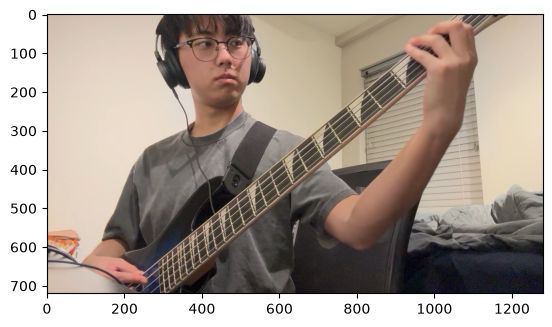

In [92]:
video_path = "data/LC FA26 Audition - OUT THERE Strollin'.mov"
frame = get_frame_from_video(video_path, 360)
imshow_cv(frame)

In [93]:
img_bgr = frame

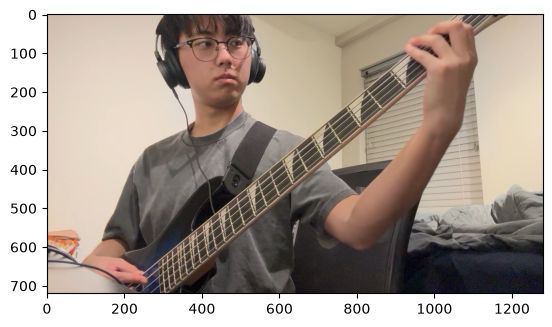

In [94]:
bass_bgr = img_bgr
imshow_cv(bass_bgr)

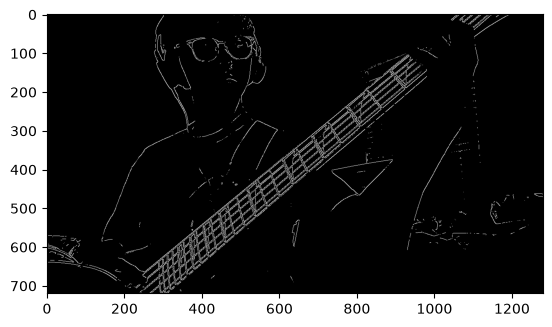

In [95]:
bass_edges_gray = bass_bgr.copy()
bass_edges_gray = cv2.Canny(bass_edges_gray, 300, 300, None, 3)
imshow_cv(bass_edges_gray)

54 lines detected
Found 52 fretboard lines


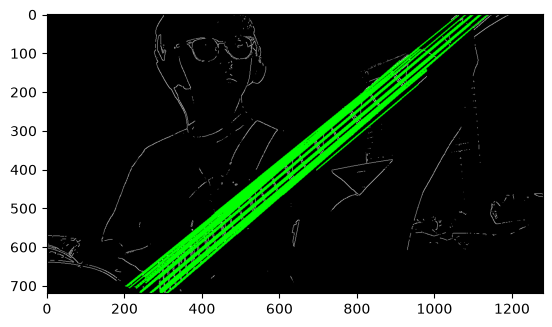

In [101]:
fretboard_lines = cv2.HoughLinesP(bass_edges_gray, rho=1, theta=np.pi/180, threshold=100, minLineLength=200, maxLineGap = 100)

fretboard_lines_bgr = cv2.cvtColor(bass_edges_gray.copy(), cv2.COLOR_GRAY2BGR)

fretboard_angles = np.arctan((fretboard_lines[:,3] - fretboard_lines[:,1])/(fretboard_lines[:,2] - fretboard_lines[:,0]))
fretboard_angles = np.where(fretboard_angles > 0, fretboard_angles, np.pi + fretboard_angles)
fretboard_angle = np.mean(fretboard_angles)

fretboard_lines_filtered = []
angle_tolerance = np.pi/12
for i in range(fretboard_angles.shape[0]):
    if fretboard_angles[i] < fretboard_angle + angle_tolerance and fretboard_angles[i] > fretboard_angle - angle_tolerance:
        fretboard_lines_filtered.append(fretboard_lines[i])
fretboard_lines_filtered = np.array(fretboard_lines_filtered)

print(f"{fretboard_lines.shape[0]} lines detected")
print(f"Found {fretboard_lines_filtered.shape[0]} fretboard lines")

for line in fretboard_lines_filtered:
    x1, y1, x2, y2 = line
    cv2.line(fretboard_lines_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
imshow_cv(fretboard_lines_bgr)

hull_mean: (650.7857142857143, 399.5)


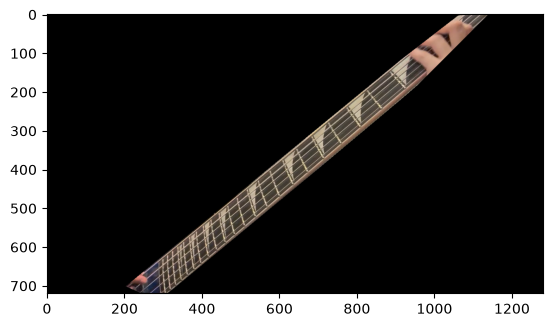

In [102]:
fretboard_pts = np.concatenate([fretboard_lines_filtered[:,:2], fretboard_lines_filtered[:,2:]])
fretboard_hull = cv2.convexHull(fretboard_pts)
hull_mean_x = np.mean(fretboard_hull[:,0,0])
hull_mean_y = np.mean(fretboard_hull[:,0,1])
print(f"hull_mean: ({hull_mean_x}, {hull_mean_y})")
fretboard_mask = np.zeros(bass_bgr.shape[:2], dtype=np.uint8)
cv2.fillConvexPoly(fretboard_mask, fretboard_hull, 1)
fretboard_edges_gray = bass_edges_gray*fretboard_mask

imshow_cv(img_bgr*fretboard_mask[:,:,np.newaxis])

In [103]:
bass_lines = cv2.HoughLinesP(fretboard_edges_gray, rho=1, theta=np.pi/180, threshold=5, minLineLength=10, maxLineGap=5)
print(f"{bass_lines.shape[0]} lines detected")

571 lines detected


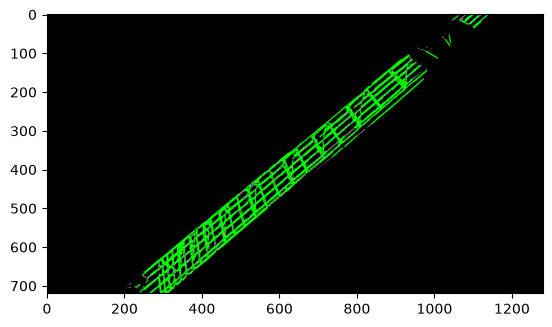

In [105]:
bass_lines_bgr = cv2.cvtColor(fretboard_edges_gray.copy(), cv2.COLOR_GRAY2BGR)
if bass_lines is not None:
    for line in bass_lines:
        x1, y1, x2, y2 = line
        cv2.line(bass_lines_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
plt.imshow(bass_lines_bgr[:,:,::-1])

In [106]:
h_lines = []
v_lines = []
angles = np.arctan((bass_lines[:,3] - bass_lines[:,1])/(bass_lines[:,2] - bass_lines[:,0]))
angles = np.where(angles > 0, angles, angles + np.pi)
angle_tolerance = np.pi/12
for i in range(bass_lines.shape[0]):
    if angles[i] < fretboard_angle + angle_tolerance and angles[i] > fretboard_angle - angle_tolerance:
        h_lines.append(bass_lines[i])
    else:
        v_lines.append(bass_lines[i])

/var/folders/y4/j_j96x_n7s752kjsc2ykn9fc0000gn/T/ipykernel_36465/118260239.py:3: RuntimeWarning: divide by zero encountered in divide
  angles = np.arctan((bass_lines[:,3] - bass_lines[:,1])/(bass_lines[:,2] - bass_lines[:,0]))


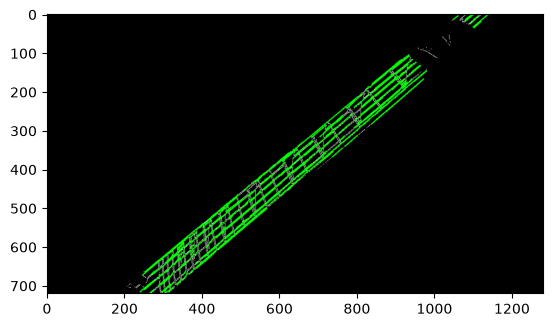

In [107]:
bass_h_lines_bgr = cv2.cvtColor(fretboard_edges_gray.copy(), cv2.COLOR_GRAY2BGR)
if h_lines is not None:
    for line in h_lines:
        x1, y1, x2, y2 = line
        cv2.line(bass_h_lines_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
imshow_cv(bass_h_lines_bgr)

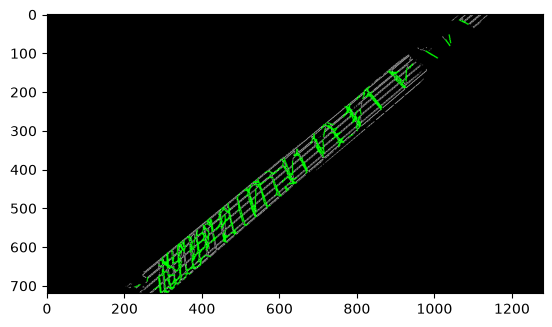

In [108]:
bass_v_lines_bgr = cv2.cvtColor(fretboard_edges_gray.copy(), cv2.COLOR_GRAY2BGR)
if v_lines is not None:
    for line in v_lines:
        x1, y1, x2, y2 = line
        cv2.line(bass_v_lines_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
imshow_cv(bass_v_lines_bgr)

# Hand Landmarking

In [87]:
model_path = 'hand_landmarker.task'
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode
options = HandLandmarkerOptions(
    base_options = BaseOptions(model_asset_path='hand_landmarker.task'),
    running_mode = VisionRunningMode.IMAGE)
landmarker = HandLandmarker.create_from_options(options)

I0000 00:00:1787857109.314230 8393983 gl_context.cc:357] GL version: 2.1 (2.1 ATI-6.1.13), renderer: AMD Radeon Pro 5300M OpenGL Engine
W0000 00:00:1787857109.336254 8460609 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787857109.357352 8460616 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [88]:
def print_hand_landmark_z(result):
    index_lm        = round(result.hand_landmarks[0][8].z, 4)
    middle_lm       = round(result.hand_landmarks[0][12].z, 4)
    ring_lm         = round(result.hand_landmarks[0][16].z, 4)
    pinky_lm        = round(result.hand_landmarks[0][20].z, 4)
    index_global    = round(result.hand_world_landmarks[0][8].z, 4)
    middle_global   = round(result.hand_world_landmarks[0][12].z, 4)
    ring_global     = round(result.hand_world_landmarks[0][16].z, 4)
    pinky_global    = round(result.hand_world_landmarks[0][20].z, 4)
    print("Landmarker result z positions")
    print("\tIndex\t\tMiddle\t\tRing\t\tPinky")
    print(f"lm\t{index_lm}\t\t{middle_lm}\t\t{ring_lm}\t\t{pinky_lm}")
    print(f"global\t{index_global}\t\t{middle_global}\t\t{ring_global}\t\t{pinky_global}")

HandLandmarkerResult(handedness=[[Category(index=1, score=0.9767040014266968, display_name='Left', category_name='Left')]], hand_landmarks=[[NormalizedLandmark(x=0.8049590587615967, y=0.384280800819397, z=-4.3703306573661393e-07, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8316838145256042, y=0.29998719692230225, z=0.022971266880631447, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8373011946678162, y=0.21736536920070648, z=0.026469524949789047, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8265343308448792, y=0.1509392112493515, z=0.02521023526787758, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8049411773681641, y=0.11248703300952911, z=0.022946326062083244, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8594440221786499, y=0.16687321662902832, z=-0.003329354804009199, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8550913333892822, y=0.05132770538330078, z=-0.012275271117687225, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.82

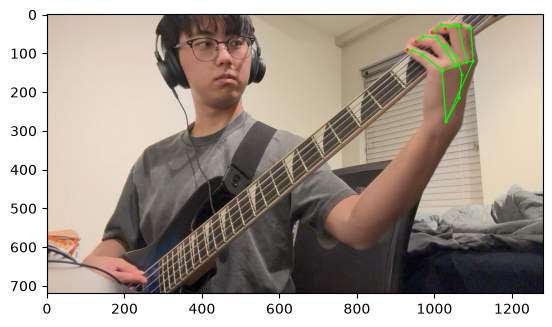

In [89]:
mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
landmarker_result = landmarker.detect(mp_img)
print(landmarker_result)
plt.imshow(draw_hand_landmarks(img_bgr, landmarker_result)[:,:,::-1])

In [90]:
print_hand_landmark_z(landmarker_result)

Landmarker result z positions
	Index		Middle		Ring		Pinky
lm	-0.0098		-0.0129		-0.0208		-0.0332
global	0.056		0.0413		0.0398		0.0266
